# Celsius to Fahrenheit Converter using a PyTorch MLP

This notebook trains a small **Multi-Layer Perceptron (MLP)** with PyTorch to learn the
linear mapping between Celsius and Fahrenheit temperatures:

$$F = C \times \frac{9}{5} + 32$$

## Contents
1. Imports & reproducibility setup
2. Synthetic data generation
3. Model definition
4. Training loop (with loss & accuracy tracking)
5. Training curves (loss & accuracy)
6. Evaluation on the held-out test set from the issue
7. Conclusion

Closes: CrossCures/crosscures#1


In [1]:
import random

import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# Reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 1. Synthetic Data Generation

We generate our own training data by sampling random Celsius values from a wide range
(covering everything from very cold winter days to boiling water and beyond) and computing
the exact Fahrenheit value using the true conversion formula. This gives the MLP plenty of
examples to learn the underlying linear relationship.


In [2]:
def celsius_to_fahrenheit(celsius: torch.Tensor) -> torch.Tensor:
    """Exact Celsius -> Fahrenheit conversion, used to label our synthetic data."""
    return celsius * 9.0 / 5.0 + 32.0


def generate_dataset(
    num_samples: int,
    low: float = -50.0,
    high: float = 150.0,
    seed: int | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Generate a synthetic (Celsius, Fahrenheit) dataset.

    Args:
        num_samples: Number of (C, F) pairs to generate.
        low: Minimum Celsius value to sample.
        high: Maximum Celsius value to sample.
        seed: Optional seed for reproducible sampling.

    Returns:
        Tuple of (celsius, fahrenheit) tensors, each of shape (num_samples, 1).
    """
    generator = torch.Generator().manual_seed(seed) if seed is not None else None
    celsius = torch.empty(num_samples, 1).uniform_(low, high, generator=generator)
    fahrenheit = celsius_to_fahrenheit(celsius)
    return celsius, fahrenheit


def normalize(x: torch.Tensor, mean: float, std: float) -> torch.Tensor:
    """Standardize a tensor using a given mean/std."""
    return (x - mean) / std


# Generate train/validation splits from random samples
train_celsius, train_fahrenheit = generate_dataset(num_samples=2000, seed=SEED)
val_celsius, val_fahrenheit = generate_dataset(num_samples=400, seed=SEED + 1)

# Normalize inputs for stable training; keep the stats to reuse at inference time
celsius_mean = train_celsius.mean().item()
celsius_std = train_celsius.std().item()

train_celsius_norm = normalize(train_celsius, celsius_mean, celsius_std).to(device)
train_fahrenheit = train_fahrenheit.to(device)
val_celsius_norm = normalize(val_celsius, celsius_mean, celsius_std).to(device)
val_fahrenheit = val_fahrenheit.to(device)

print(f"Train samples: {train_celsius.shape[0]}, Validation samples: {val_celsius.shape[0]}")
print(f"Celsius normalization -> mean: {celsius_mean:.2f}, std: {celsius_std:.2f}")


Train samples: 2000, Validation samples: 400
Celsius normalization -> mean: 48.99, std: 57.47


## 2. Model Definition

A tiny MLP is more than enough to learn a linear function, but using a couple of hidden
layers with a non-linear activation demonstrates that the network can still recover the
underlying linear relationship purely from data.


In [3]:
class CelsiusToFahrenheitMLP(nn.Module):
    """Small MLP that maps a (normalized) Celsius value to a Fahrenheit value."""

    def __init__(self, hidden_size: int = 16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def build_model(hidden_size: int = 16) -> CelsiusToFahrenheitMLP:
    """Factory function to create a fresh model instance."""
    return CelsiusToFahrenheitMLP(hidden_size=hidden_size).to(device)


## 3. Training Loop

We track two metrics per epoch:

- **Loss**: Mean Squared Error (MSE) between predicted and true Fahrenheit values.
- **Accuracy**: Percentage of predictions within a small tolerance (±1°F by default) of the
  true value. This gives an interpretable "how often are we basically right" metric for a
  regression problem.


In [4]:
def compute_accuracy(predictions: torch.Tensor, targets: torch.Tensor, tolerance: float = 1.0) -> float:
    """Fraction (0-1) of predictions within `tolerance` degrees Fahrenheit of the target."""
    within_tolerance = (torch.abs(predictions - targets) <= tolerance).float()
    return within_tolerance.mean().item()


def train_model(
    model: nn.Module,
    train_x: torch.Tensor,
    train_y: torch.Tensor,
    val_x: torch.Tensor,
    val_y: torch.Tensor,
    epochs: int = 2000,
    lr: float = 0.01,
    tolerance: float = 1.0,
) -> dict:
    """Train `model` and return a history dict of loss/accuracy for train and validation."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        train_preds = model(train_x)
        loss = criterion(train_preds, train_y)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(val_x)
            val_loss = criterion(val_preds, val_y)
            train_acc = compute_accuracy(train_preds, train_y, tolerance)
            val_acc = compute_accuracy(val_preds, val_y, tolerance)

        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss.item())
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if (epoch + 1) % 200 == 0 or epoch == 0:
            print(
                f"Epoch {epoch + 1:4d}/{epochs} | "
                f"train_loss={loss.item():.4f} val_loss={val_loss.item():.4f} | "
                f"train_acc={train_acc:.2%} val_acc={val_acc:.2%}"
            )

    return history


## 4. Run Training

In [5]:
model = build_model(hidden_size=16)
history = train_model(
    model,
    train_celsius_norm,
    train_fahrenheit,
    val_celsius_norm,
    val_fahrenheit,
    epochs=2000,
    lr=0.05,
    tolerance=1.0,
)


Epoch    1/2000 | train_loss=25164.0176 val_loss=26683.1504 | train_acc=1.15% val_acc=0.50%
Epoch  200/2000 | train_loss=179.4544 val_loss=127.4226 | train_acc=78.25% val_acc=77.75%


Epoch  400/2000 | train_loss=163.0846 val_loss=113.7082 | train_acc=78.80% val_acc=78.25%
Epoch  600/2000 | train_loss=144.0845 val_loss=98.0870 | train_acc=80.35% val_acc=80.75%


Epoch  800/2000 | train_loss=124.4370 val_loss=82.3168 | train_acc=82.70% val_acc=82.25%
Epoch 1000/2000 | train_loss=105.4940 val_loss=67.4768 | train_acc=84.95% val_acc=86.00%


Epoch 1200/2000 | train_loss=88.0492 val_loss=54.1769 | train_acc=86.70% val_acc=87.50%
Epoch 1400/2000 | train_loss=72.4707 val_loss=42.6540 | train_acc=87.90% val_acc=89.00%


Epoch 1600/2000 | train_loss=58.9544 val_loss=33.0360 | train_acc=89.35% val_acc=89.75%
Epoch 1800/2000 | train_loss=47.4685 val_loss=25.2575 | train_acc=90.05% val_acc=90.75%


Epoch 2000/2000 | train_loss=37.8934 val_loss=19.1366 | train_acc=90.75% val_acc=92.75%


## 5. Training Curves

Plot the loss and accuracy over the course of training for both the training and
validation splits.


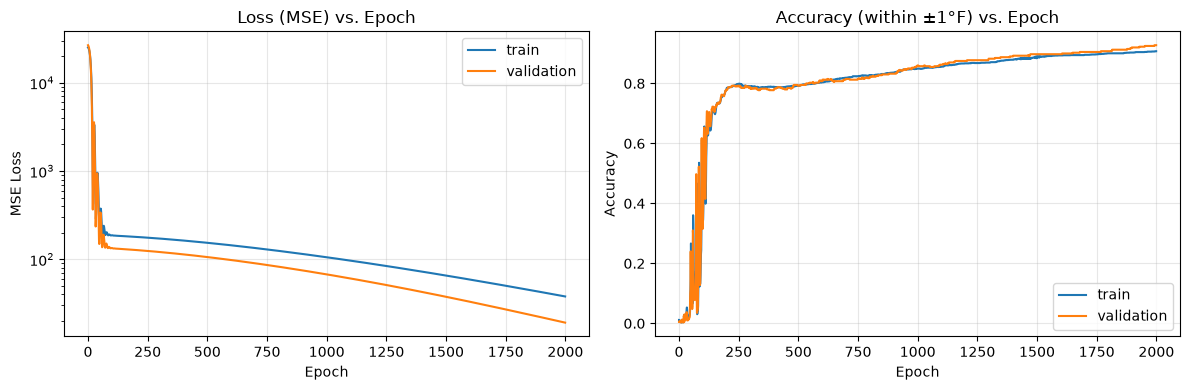

In [6]:
def plot_history(history: dict) -> None:
    """Plot loss and accuracy curves side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["val_loss"], label="validation")
    axes[0].set_title("Loss (MSE) vs. Epoch")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE Loss")
    axes[0].set_yscale("log")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history["train_acc"], label="train")
    axes[1].plot(history["val_acc"], label="validation")
    axes[1].set_title("Accuracy (within ±1°F) vs. Epoch")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_history(history)


## 6. Evaluation on the Issue's Test Set

Finally, we evaluate the trained model on the exact test cases provided in the GitHub
issue and report the per-row predictions plus overall test accuracy.


In [7]:
test_cases = [
    (-20, -4.0, "Very cold winter day"),
    (-10, 14.0, "Below freezing"),
    (0, 32.0, "Freezing point of water"),
    (10, 50.0, "Cool autumn day"),
    (20, 68.0, "Room temperature"),
    (25, 77.0, "Warm summer day"),
    (30, 86.0, "Hot summer day"),
    (37, 98.6, "Normal human body temperature"),
    (40, 104.0, "Very hot weather"),
    (100, 212.0, "Boiling point of water"),
]


def evaluate_on_test_cases(model: nn.Module, test_cases: list, tolerance: float = 1.0) -> None:
    """Run the model on the provided test cases and report predictions + accuracy."""
    celsius_values = torch.tensor([[row[0]] for row in test_cases], dtype=torch.float32)
    fahrenheit_targets = torch.tensor([[row[1]] for row in test_cases], dtype=torch.float32)

    celsius_norm = normalize(celsius_values, celsius_mean, celsius_std).to(device)
    fahrenheit_targets = fahrenheit_targets.to(device)

    model.eval()
    with torch.no_grad():
        predictions = model(celsius_norm)

    mae = torch.mean(torch.abs(predictions - fahrenheit_targets)).item()
    accuracy = compute_accuracy(predictions, fahrenheit_targets, tolerance)

    print(f"{'Celsius':>8} | {'Expected F':>10} | {'Predicted F':>11} | {'Abs Error':>9} | Description")
    print("-" * 80)
    for (celsius, expected, description), pred in zip(test_cases, predictions):
        pred_value = pred.item()
        error = abs(pred_value - expected)
        print(f"{celsius:8.1f} | {expected:10.1f} | {pred_value:11.2f} | {error:9.2f} | {description}")

    print("-" * 80)
    print(f"Test MAE: {mae:.3f}°F")
    print(f"Test Accuracy (within ±{tolerance}°F): {accuracy:.2%}")


evaluate_on_test_cases(model, test_cases, tolerance=1.0)


 Celsius | Expected F | Predicted F | Abs Error | Description
--------------------------------------------------------------------------------
   -20.0 |       -4.0 |       -4.07 |      0.07 | Very cold winter day
   -10.0 |       14.0 |       13.91 |      0.09 | Below freezing
     0.0 |       32.0 |       31.95 |      0.05 | Freezing point of water
    10.0 |       50.0 |       49.97 |      0.03 | Cool autumn day
    20.0 |       68.0 |       67.98 |      0.02 | Room temperature
    25.0 |       77.0 |       76.99 |      0.01 | Warm summer day
    30.0 |       86.0 |       86.00 |      0.00 | Hot summer day
    37.0 |       98.6 |       98.62 |      0.02 | Normal human body temperature
    40.0 |      104.0 |      104.01 |      0.01 | Very hot weather
   100.0 |      212.0 |      212.00 |      0.00 | Boiling point of water
--------------------------------------------------------------------------------
Test MAE: 0.030°F
Test Accuracy (within ±1.0°F): 100.00%


## 7. Conclusion

The MLP successfully learns the linear Celsius-to-Fahrenheit relationship purely from
randomly generated synthetic data, generalizing well to the real-world test cases
provided in the issue (very cold days, freezing/boiling points of water, body
temperature, etc.).
